# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# A good test to do is if you can see the contents of the directory in which you work on your google drive.
# Here "My Drive" refers to the "root" of your google drive.
# By default your notebook should be in a directory called Colab Notebooks.
# This template assumes all files you want to read in are copied in the
# same directory. Note the slash at the end of the first line.

#==============================================================================================================
#pathcrabtemplate = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
pathcrabtemplate = rootpathdrive+'/'+'My Drive/Colab Notebooks/CrabPulsar/Crab_pulsar_template/' #Sara's directory
#==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathcrabtemplate):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.

['README.md', 'Crab Pulsar Timing.ipynb', 'LICENSE', 'template.txt', '.gitignore', 'Untitled0.ipynb', '20251007_100808_B0329+54.npz', '20251007_110422_B0950+08.npz', '20251007_121203_B1933+16.npz', '20251007_134605_B2021+51.npz', 'Searching for Pulsars.ipynb', 'Copy of Searching for Pulsars.ipynb', 'Copy of Another copy of Searching for Pulsars.ipynb', '2025_ssb.txt', '20251021_071206_B0531+21.npz.toas.txt', '20251007_121203_B1933+16.npz.toas.txt', 'MasterDocument.ipynb', '20251111_091248_B1133+16.npz', '20251111_054931_B0531+21.npz', '20251111_114643_B1929+10.npz', 'Dedispersion and data visualisation.ipynb', 'Pulsar Results.gslides', 'Copy of Crab Pulsar Timing.ipynb', '20251111_054931_B0531+21.npz.toas.txt', 'Make Time of Arrivals.ipynb']


In [4]:
# Specify the file with ToAs you want to work on.
toafile  = os.path.join(pathcrabtemplate,"20251111_054931_B0531+21.npz.toas.txt")
baryfile = os.path.join(pathcrabtemplate,"2025_ssb.txt") # ssb_2022 will work for all of 2022.

# Read the barycentre file... Read the numpy loadtxt page to understand what this does...
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile,unpack=True)
year = year
month = month
day = day
xpos = xpos
ypos = ypos
zpos = zpos

print(year)
# @todo: Load in your ToAs in a similar way.
toa_day, toa_uncertainty = np.loadtxt(toafile,unpack=True)

[2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 20

In [5]:
print(toa_day)
#print(year, month, day)

[60990.24409758 60990.24629663 60990.24861159 60990.25092615
 60990.2532405  60990.25555574 60990.25787052 60990.2601853
 60990.26250008 60990.26481485 60990.26712963 60990.26944402
 60990.27175958 60990.27407413 60990.27638874 60990.2787034
 60990.2810183  60990.28333326 60990.28564778 60990.28796263
 60990.29027741 60990.29259217 60990.29490736 60990.29722214
 60990.29953692 60990.3018517  60990.30416648 60990.30648125
 60990.30879603 60990.31111081 60990.31342559 60990.31574037
 60990.31805575 60990.32037031 60990.32268549 60990.32500026
 60990.32731504 60990.32962982 60990.33194421 60990.33425899
 60990.33657377 60990.33888904 60990.34062473]


In [6]:
from astropy.time import Time

def ymd_to_mjd_array_astropy(year, month, day):
    """
    Convert year, month, day (0h UT) to Modified Julian Date (MJD) using Astropy.
    Supports scalar or NumPy array inputs.
    """
    # Create datetime strings in ISO format
    dates = [f"{int(y)}-{int(m):02d}-{int(d):02d}" for y, m, d in zip(year, month, day)]

    # Create Astropy Time object
    t = Time(dates, format='iso')

    # Return MJD
    return t.mjd

# Use Astropy for conversion
barycentre_mjd = ymd_to_mjd_array_astropy(year, month, day)

# Step 2: Apply the date window
lower_limit = 60968
upper_limit = 60971

measurement_mask = (barycentre_mjd >= lower_limit) & (barycentre_mjd <= upper_limit)

# Step 3: Filter all arrays
barycentre_mjd_new = barycentre_mjd[measurement_mask]
xpos_new = xpos[measurement_mask]
ypos_new = ypos[measurement_mask]
zpos_new = zpos[measurement_mask]

print(barycentre_mjd_new)

[60968. 60969. 60970. 60971.]


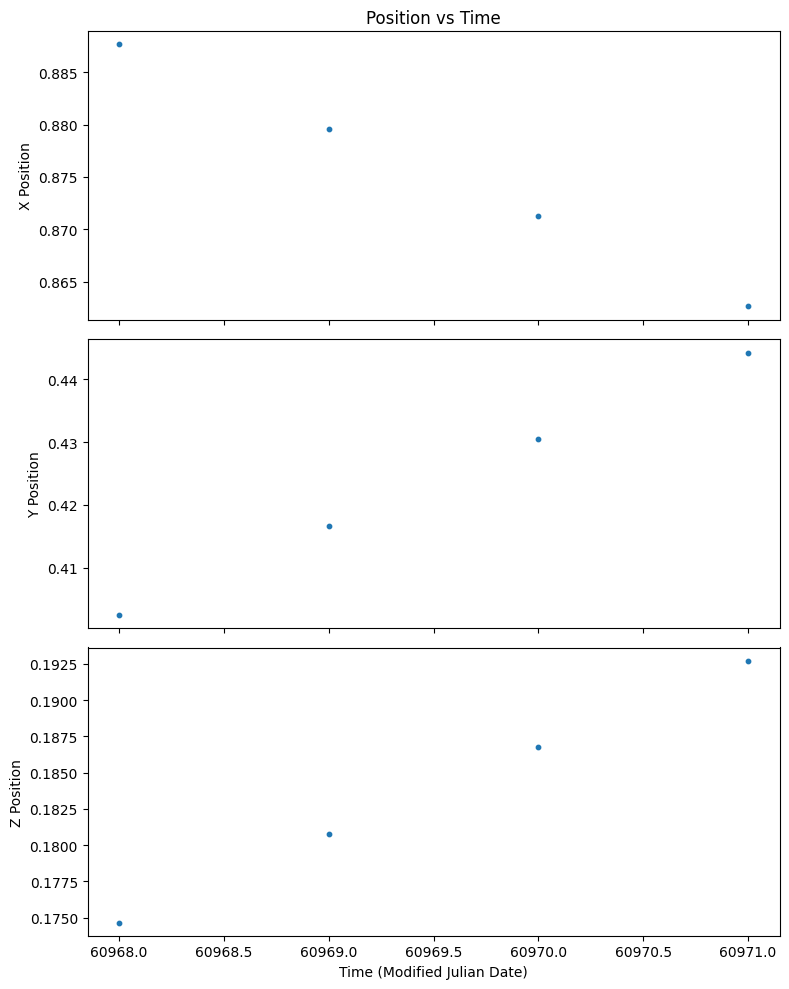

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# X position
axes[0].scatter(barycentre_mjd_new, xpos_new, s=10)
axes[0].set_ylabel("X Position")
axes[0].set_title("Position vs Time")

# Y position
axes[1].scatter(barycentre_mjd_new, ypos_new, s=10)
axes[1].set_ylabel("Y Position")

# Z position
axes[2].scatter(barycentre_mjd_new, zpos_new, s=10)
axes[2].set_ylabel("Z Position")
axes[2].set_xlabel("Time (Modified Julian Date)")

plt.tight_layout()
plt.show()


## Interpolation
The Earth-barycentre vector is only given once per day (at 0 UT) in your input file. Therefore you will need to [interpolate](https://en.wikipedia.org/wiki/Interpolation) to get the vector at the time of each of your ToAs.

The below is an example code showing interpolation of a simple sinusoid function. Make sure you understand what this code is doing, then replace it with a function to interpolate your x, y and z positions at the times of your ToAs.

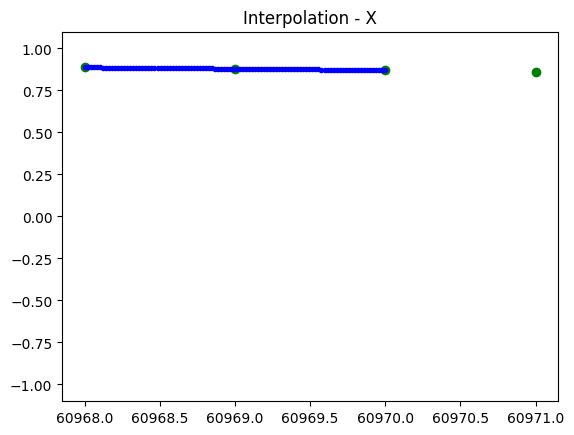

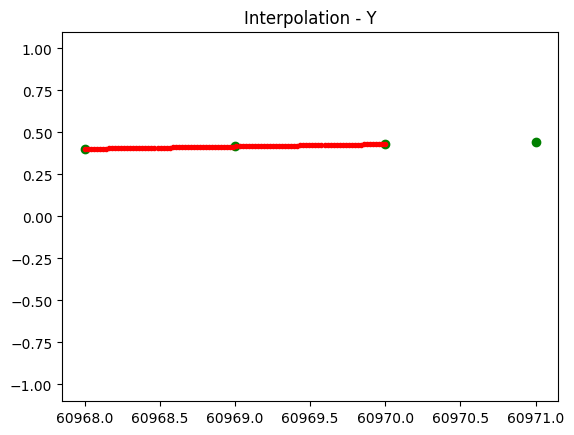

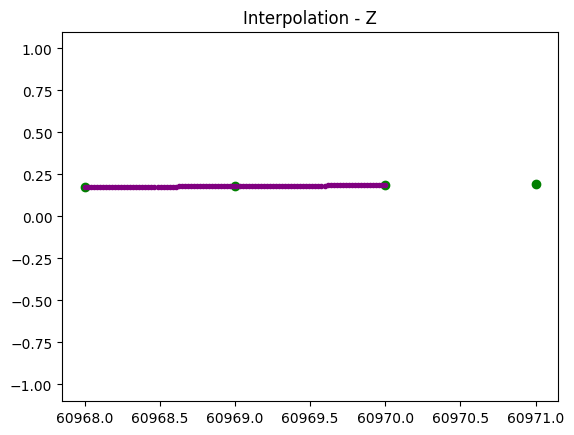

Interpolated coordinates at TOA days:
X positions: [0.64496123 0.64493073 0.64489861 0.6448665  0.6448344  0.64480227
 0.64477016 0.64473804 0.64470592 0.6446738  0.64464167 0.64460955
 0.64457742 0.64454529 0.64451317 0.64448104 0.64444891 0.64441677
 0.64438464 0.6443525  0.64432037 0.64428823 0.64425608 0.64422394
 0.6441918  0.64415965 0.64412751 0.64409536 0.64406321 0.64403106
 0.64399891 0.64396676 0.64393459 0.64390244 0.64387028 0.64383812
 0.64380596 0.6437738  0.64374164 0.64370948 0.64367731 0.64364514
 0.64362101]
Y positions: [0.68425253 0.68427727 0.68430332 0.68432936 0.68435539 0.68438144
 0.68440748 0.68443352 0.68445956 0.6844856  0.68451163 0.68453767
 0.68456371 0.68458975 0.68461578 0.68464181 0.68466785 0.68469388
 0.68471991 0.68474594 0.68477198 0.68479801 0.68482404 0.68485007
 0.6848761  0.68490212 0.68492815 0.68495418 0.6849802  0.68500623
 0.68503225 0.68505828 0.68508431 0.68511033 0.68513635 0.68516237
 0.68518839 0.68521441 0.68524043 0.68526644 0.68529

In [8]:
# Interpolation Valyes
start_point = 0
interp_number=3

# For x coordinate
x = barycentre_mjd_new
y_x = xpos_new

interp_function_x = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_x[start_point:start_point+interp_number])

x2 = np.linspace(x[start_point], x[start_point + interp_number - 1], 100)
y2_x = interp_function_x(x2)

plt.plot(x, y_x, 'o', color='green')
plt.plot(x2, y2_x, '.', color='blue')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - X")
plt.show()

xpos_at_times = interp_function_x(toa_day)

# For y coordinate
y_y = ypos_new

interp_function_y = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_y[start_point:start_point+interp_number])

y2_y = interp_function_y(x2)

plt.plot(x, y_y, 'o', color='green')
plt.plot(x2, y2_y, '.', color='red')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Y")
plt.show()

ypos_at_times = interp_function_y(toa_day)

# For z coordinate
y_z = zpos_new

interp_function_z = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_z[start_point:start_point+interp_number])

y2_z = interp_function_z(x2)

plt.plot(x, y_z, 'o', color='green')
plt.plot(x2, y2_z, '.', color='purple')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Z")
plt.show()

zpos_at_times = interp_function_z(toa_day)

# Print or save all interpolated coordinates
print("Interpolated coordinates at TOA days:")
print(f"X positions: {xpos_at_times}")
print(f"Y positions: {ypos_at_times}")
print(f"Z positions: {zpos_at_times}")


coordinates_array = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))

In [9]:
# Example: check how well the interpolation predicts nearby actual data points
actual_values = ypos_new[start_point:start_point+interp_number+1]  # one more real point
predicted_values = interp_function_y(x[start_point:start_point+interp_number+1])
residuals = actual_values - predicted_values
error = np.sqrt(np.mean(residuals**2))  # RMS error
print("RMS interpolation error:", error)


RMS interpolation error: 2.340674442403175e-06


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``


Altitudes (deg): [39d50m54.65317675s 39d23m40.05326191s 38d54m52.34104576s
 38d25m58.18274465s 37d56m57.81810841s 37d27m50.78052249s
 36d58m38.45505121s 36d29m20.84363538s 35d59m58.29093835s
 35d30m31.13251041s 35d00m59.69565327s 34d31m24.6034452s
 34d01m44.96556934s 33d32m02.76910873s 33d02m17.49219539s
 32d32m29.44475849s 32d02m38.75865847s 31d32m45.85999969s
 31d02m51.41964061s 30d32m55.10388839s 30d02m57.5037232s
 29d32m58.84093759s 29d02m59.02097132s 28d32m58.95859501s
 28d02m58.58496594s 27d32m58.14758089s 27d02m57.89242741s
 26d32m58.06120612s 26d02m58.89085179s 25d33m00.62011614s
 25d03m03.47932204s 24d33m07.69975534s 24d03m13.04150217s
 23d33m20.83216777s 23d03m30.19342455s 22d33m42.11873581s
 22d03m56.52482124s 21d34m13.63071542s 21d04m33.9529665s
 20d34m57.10531749s 20d05m23.60305649s 19d35m53.2787715s
 19d13m48.59169701s]
Azimuths (deg): [252d29m57.23950885s 253d15m03.59905671s 254d02m06.56239408s
 254d48m43.13729407s 255d34m54.37562435s 256d20m42.39207631s
 257d06m06.34957

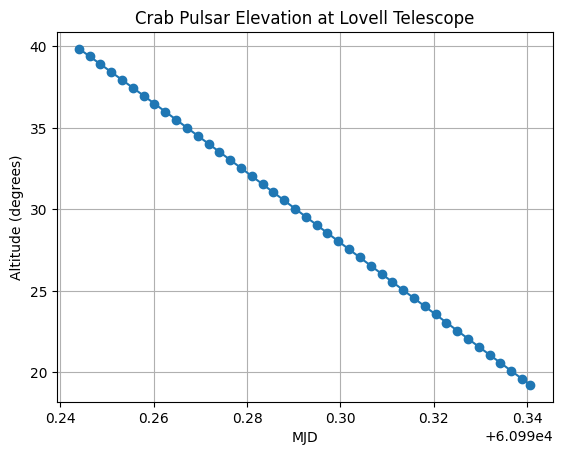

Earth delay (s): [0.0136322  0.01350233 0.01336415 0.0132245  0.01308342 0.01294085
 0.01279693 0.01265164 0.01250502 0.0123571  0.01220791 0.01205751
 0.01190583 0.01175305 0.01159911 0.01144407 0.01128794 0.01113077
 0.01097261 0.01081346 0.01065338 0.01049239 0.0103305  0.0101678
 0.01000429 0.00984002 0.00967502 0.00950931 0.00934295 0.00917596
 0.00900837 0.00884023 0.00867153 0.0085024  0.00833278 0.00816277
 0.00799239 0.00782167 0.00765067 0.00747938 0.00730785 0.0071361
 0.00700723]


In [10]:
from astropy import constants as const


# Crab Pulsar position
pulsarpos = coord.SkyCoord(ra="05:34:31.9", dec="+22:00:52.0",
                           unit=(u.hourangle, u.deg))

lovellpos = coord.EarthLocation(
    lat="53:14:09", lon="-2:18:23", height=126.3*u.m
)

times = Time(toa_day, format='mjd', scale='utc')

# Transform to AltAz
altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=lovellpos))

# Check output
print("Altitudes (deg):", altaz.alt)
print("Azimuths (deg):", altaz.az)

# Optional plot
plt.plot(times.mjd, altaz.alt.deg, 'o-')
plt.xlabel("MJD")
plt.ylabel("Altitude (degrees)")
plt.title("Crab Pulsar Elevation at Lovell Telescope")
plt.grid(True)
plt.show()


# Get altitude in radians
elevation_rad = altaz.alt.to(u.rad).value  # numeric array in radians

# Constants
R_earth = const.R_earth.value  # meters
c = const.c.value              # m/s

# Compute Earth delay
earth_delay = (R_earth * np.sin(elevation_rad)) / c  # seconds

print("Earth delay (s):", earth_delay)


## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.
$$
\Delta_{Rsun} = \frac{1}{c} \vec{r}_{vec} \cdot \hat{\vec{s}} = -\frac{1}{c} \left( \vec{r}_{SSB} + \vec{r}_{EO} \right) \cdot \hat{\vec{s}}
$$


[403.2071302  403.21881639 403.23111668 403.24341291 403.25570613
 403.26800223 403.28029403 403.29258402 403.30487225 403.31715874
 403.3294435  403.34172453 403.35401013 403.36628878 403.37856615
 403.3908422  403.40311804 403.41539274 403.42766362 403.43993488
 403.45220435 403.46447236 403.47674135 403.48900688 403.50127115
 403.51353424 403.52579615 403.5380569  403.55031657 403.56257515
 403.57483272 403.58708928 403.59934808 403.61160163 403.62385749
 403.63611042 403.64836254 403.66061388 403.67286239 403.68511227
 403.6973615  403.7096127  403.71879662] s
Roemer delay (s) for each TOA:
[403.2071302  403.21881639 403.23111668 403.24341291 403.25570613
 403.26800223 403.28029403 403.29258402 403.30487225 403.31715874
 403.3294435  403.34172453 403.35401013 403.36628878 403.37856615
 403.3908422  403.40311804 403.41539274 403.42766362 403.43993488
 403.45220435 403.46447236 403.47674135 403.48900688 403.50127115
 403.51353424 403.52579615 403.5380569  403.55031657 403.56257515
 4

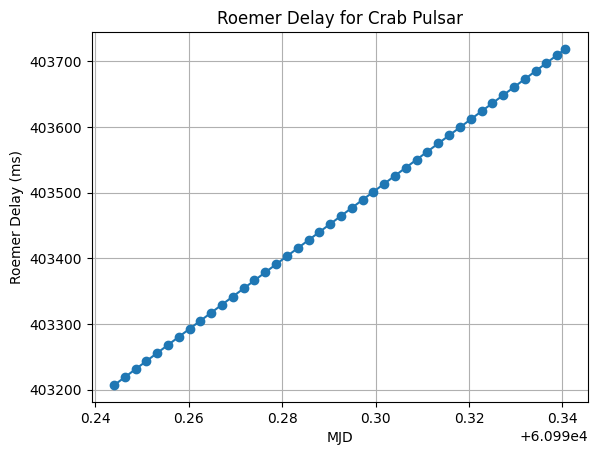

In [11]:
c = const.c

# Barycentre positions at ToA and subsequently our observation coords (centre of earth)
psr_x = xpos_at_times
psr_y = ypos_at_times
psr_z = zpos_at_times
r_ssb = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))  # Earth to barycentre vector at TOA

# Converting pulsar's RA and Dec coords into cartesian
pulsar_cart = pulsarpos.icrs.cartesian
s_hat = np.array([pulsar_cart.x.value,
                  pulsar_cart.y.value,
                  pulsar_cart.z.value])
s_hat /= np.linalg.norm(s_hat)  # ensure it's a unit vector

r_ssb_q = r_ssb * const.au  # corrected r_ssb in metres

# Fix: Add units to r_sine to make it consistent
r_sine = (R_earth * np.sin(elevation_rad)) * u.m  # Add units explicitly

# Calculate the dot product and ensure proper units
dot_product = np.dot(r_ssb_q, s_hat)  # This has units of meters

roemer_delay = (1/c) * (dot_product + r_sine)

print(roemer_delay)
print("Roemer delay (s) for each TOA:")
print(roemer_delay)

plt.plot(toa_day, roemer_delay.to(u.ms), 'o-')
plt.xlabel("MJD")
plt.ylabel("Roemer Delay (ms)")
plt.title("Roemer Delay for Crab Pulsar")
plt.grid(True)
plt.show()



In [12]:
# Convert Time object to MJD values (plain numbers)
times_mjd = times.mjd  # This gives you the numerical MJD values

print("Times MJD values:", times_mjd)

# Convert Roemer delay from seconds to days (since MJD is in days)
roemer_delay_days = roemer_delay.to(u.day)

# Now add them properly
corrected_time_mjd = times_mjd + roemer_delay_days.value

print("Corrected times (MJD):", corrected_time_mjd)

# If you want to convert back to Time object:
corrected_time = Time(corrected_time_mjd, format='mjd')
print("Corrected Time objects:", corrected_time)

Times MJD values: [60990.24409758 60990.24629663 60990.24861159 60990.25092615
 60990.2532405  60990.25555574 60990.25787052 60990.2601853
 60990.26250008 60990.26481485 60990.26712963 60990.26944402
 60990.27175958 60990.27407413 60990.27638874 60990.2787034
 60990.2810183  60990.28333326 60990.28564778 60990.28796263
 60990.29027741 60990.29259217 60990.29490736 60990.29722214
 60990.29953692 60990.3018517  60990.30416648 60990.30648125
 60990.30879603 60990.31111081 60990.31342559 60990.31574037
 60990.31805575 60990.32037031 60990.32268549 60990.32500026
 60990.32731504 60990.32962982 60990.33194421 60990.33425899
 60990.33657377 60990.33888904 60990.34062473]
Corrected times (MJD): [60990.24876433 60990.25096352 60990.25327862 60990.25559332
 60990.25790781 60990.2602232  60990.26253812 60990.26485304
 60990.26716796 60990.26948288 60990.2717978  60990.27411233
 60990.27642803 60990.27874272 60990.28105748 60990.28337228
 60990.28568732 60990.28800242 60990.29031708 60990.29263208

## Residuals from a fixed period model - WORKING PROGRESS



In [13]:

# Constants
SECONDS_PER_DAY = 86400.0

# Initial model period estimate (in seconds)

print(corrected_time_mjd)

period_guess = 0.033848216371383265  # seconds

indices_to_remove = [0, 2, 3, 4, 13, 15, 17, 18, 21, 32, 41]
corrected_time_mjd = np.delete(corrected_time_mjd, indices_to_remove)
#time_elapsed = np.delete(time_elapsed, indices_to_remove)

print(corrected_time_mjd)

[60990.24876433 60990.25096352 60990.25327862 60990.25559332
 60990.25790781 60990.2602232  60990.26253812 60990.26485304
 60990.26716796 60990.26948288 60990.2717978  60990.27411233
 60990.27642803 60990.27874272 60990.28105748 60990.28337228
 60990.28568732 60990.28800242 60990.29031708 60990.29263208
 60990.294947   60990.2972619  60990.29957723 60990.30189215
 60990.30420707 60990.30652199 60990.30883691 60990.31115183
 60990.31346675 60990.31578167 60990.31809659 60990.32041151
 60990.32272704 60990.32504175 60990.32735706 60990.32967198
 60990.3319869  60990.33430182 60990.33661635 60990.33893127
 60990.34124619 60990.34356161 60990.3452974 ]
[60990.25096352 60990.2602232  60990.26253812 60990.26485304
 60990.26716796 60990.26948288 60990.2717978  60990.27411233
 60990.27642803 60990.28105748 60990.28568732 60990.29263208
 60990.294947   60990.29957723 60990.30189215 60990.30420707
 60990.30652199 60990.30883691 60990.31115183 60990.31346675
 60990.31578167 60990.31809659 60990.3

Length of residuals (old) 32
Values in residuals (old) [ 0.00000000e+00 -1.13470294e-03 -1.69384530e-04  1.35310599e-03
  4.79756440e-04 -1.54508214e-03 -1.21122546e-03 -2.39423652e-03
 -2.31395978e-03 -1.80732869e-03 -2.77398684e-03 -3.70394676e-03
 -1.94001499e-03 -1.55695702e-03 -1.96599647e-03 -3.15507691e-03
 -2.13404128e-03 -2.26449469e-03 -3.56500951e-03 -5.75299113e-04
 -3.23159940e-03 -2.84202551e-03 -2.17386556e-03 -3.62947554e-03
 -2.44735763e-03 -1.63061847e-03 -7.02444842e-04 -1.83580804e-03
 -7.52985885e-04  8.23257142e-05  2.12484354e-03  1.83931552e-03]
Length of time elapsed: 32
Time elapsed: [   0.          800.03640375 1000.04554696 1200.05470903 1400.06379001
 1600.07283201 1800.08195385 2000.05717613 2200.13398582 2600.11837583
 3000.13656418 3600.16386432 3800.17303457 4200.22511682 4400.23421352
 4600.24328381 4800.25242891 5000.26153503 5200.27060155 5400.27981328
 5600.28883391 5800.29795764 6000.30709079 6400.35911081 6600.40210958
 6800.41124776 7000.42038972

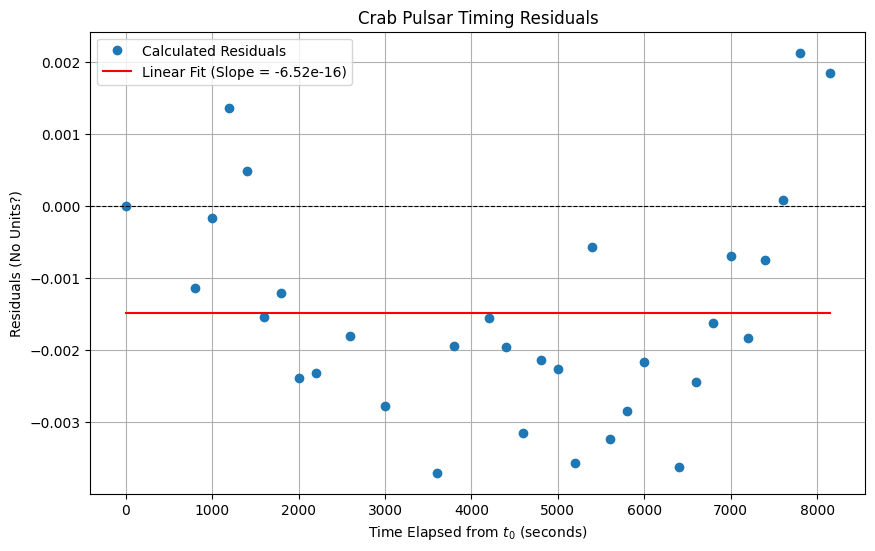

Gradient:  -6.521645160370772e-16


In [16]:
# Reference (The first corrected TOA)
t_0_mjd = corrected_time_mjd[0]

# Calculate time difference (t - t0) in MJD days
delta_t_days = corrected_time_mjd - t_0_mjd

# Convert time difference to seconds
delta_t_seconds = delta_t_days * SECONDS_PER_DAY
time_elapsed = delta_t_seconds

#print("Time elapsed (s):", time_elapsed)

# Calculate the EXPECTED number of rotations (N) based on the model
# N = (t - t0) / P_model
N = delta_t_seconds / period_guess
#print("N:", N)
# Calculate the fractional part of N (the residual in PHASE)
# fractional_part = N - floor(N)
N_integer = np.round(N)
#print("N_integer:", N_integer)


N_fraction = N - N_integer

# Calculate the RESIDUAL in TIME (seconds)
# Residual (dt) = fractional_part * P_model
residuals = N_fraction #* period_guess

print("Length of residuals (old)", len(residuals))
print("Values in residuals (old)", residuals)

print("Length of time elapsed:", len(time_elapsed))
print("Time elapsed:", time_elapsed)

residuals_new = residuals

# np.concatenate([
#     residuals[0:5],
#     residuals[5:15] + 1,
#     residuals[15:28] + 2,
#     residuals[28:32] + 3
# ])


# # Linear fitting

# # Perform a linear fit (polynomial of degree 1) to the residuals vs. time
# # polyfit returns [m, c], where m is the slope and c is the y-intercept.
# # We fit Residuals (Y) vs. Time Elapsed (X)
(slope_m, intercept_c) = np.polyfit(time_elapsed, residuals_new, 1)

fit_line = slope_m * time_elapsed + intercept_c

plt.figure(figsize=(10, 6))
plt.plot(time_elapsed, residuals_new, 'o', label='Calculated Residuals')
plt.plot(time_elapsed, fit_line, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

plt.xlabel('Time Elapsed from $t_0$ (seconds)')
plt.ylabel('Residuals (No Units?)')
plt.title(f'Crab Pulsar Timing Residuals')
plt.legend()
plt.grid(True)
plt.show()

print("Gradient: ", slope_m)



P_true: 0.03384862740161222


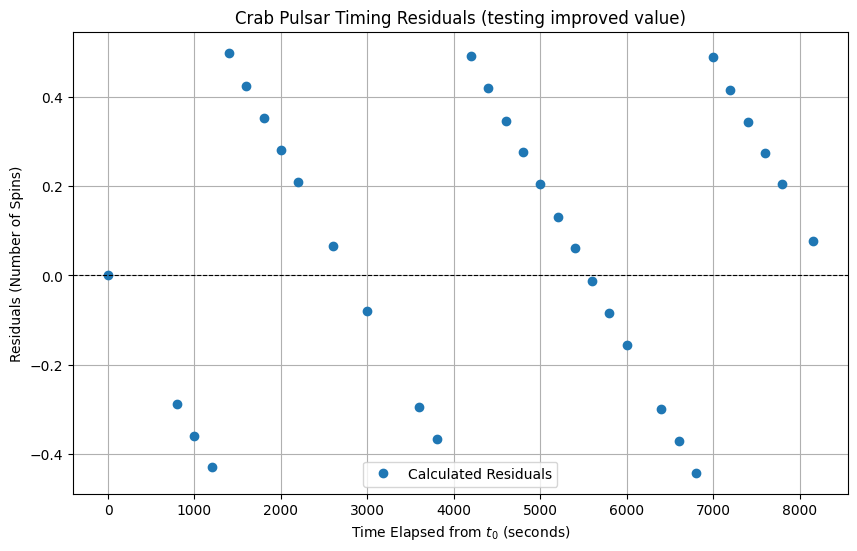

In [15]:
P_true = -1/(slope_m - 1/period_guess)
print("P_true:", P_true)

# Reference (The first corrected TOA)
t_0_mjd = corrected_time_mjd[0]

# Calculate time difference (t - t0) in MJD days
delta_t_days = corrected_time_mjd - t_0_mjd

# Convert time difference to seconds
delta_t_seconds = delta_t_days * SECONDS_PER_DAY
time_elapsed = delta_t_seconds

#print("Time elapsed (s):", time_elapsed)

# Calculate the EXPECTED number of rotations (N) based on the model
# N = (t - t0) / P_model
N = delta_t_seconds / P_true
#print("N:", N)
# Calculate the fractional part of N (the residual in PHASE)
# fractional_part = N - floor(N)
N_integer = np.round(N)
#print("N_integer:", N_integer)


N_fraction = N - N_integer

# Calculate the RESIDUAL in TIME (seconds)
# Residual (dt) = fractional_part * P_model
residuals = N_fraction

#fit_line = slope_m * time_elapsed + intercept_c

plt.figure(figsize=(10, 6))
plt.plot(time_elapsed, residuals, 'o', label='Calculated Residuals')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

plt.xlabel('Time Elapsed from $t_0$ (seconds)')
plt.ylabel('Residuals (Number of Spins)')
plt.title(f'Crab Pulsar Timing Residuals (testing improved value)')
plt.legend()
plt.grid(True)
plt.show()

#print("Gradient: ", slope_m)